# Solución — Examen Final: Random Forest aplicado al riesgo crediticio

**Dataset:** `german_credit_data.csv`  
**Variable objetivo:** `Risk` (0 = buen cliente, 1 = incumplimiento)  
**Fuente:** UCI Machine Learning Repository / Kaggle

## 1. Análisis exploratorio de datos (EDA)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('german_credit_data_updated.csv')

# El dataset original trae Risk con valores 1 y 2
# Se convierte a 0 (buen cliente) y 1 (incumplimiento)
df['Credit Risk'] = df['Credit Risk'].map({1: 0, 2: 1})


print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (954, 11)

Primeras filas:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,2,49,male,1,own,little,NaN,2096,12,education,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,1


In [8]:
print("Tipos de datos:")
print(df.dtypes)
print("\nEstadísticas descriptivas:")
df.describe()

Tipos de datos:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                 int64
dtype: object

Estadísticas descriptivas:


,Unnamed: 0,Age,Job,Credit amount,Duration,Risk
count,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000
mean,476.500000,35.501048,1.909853,3279.112159,20.780922,0.302935
std,275.540378,11.379668,0.649681,2853.315158,12.046483,0.459768
min,0.000000,19.000000,0.000000,250.000000,4.000000,0.000000
25%,238.250000,27.000000,2.000000,1360.250000,12.000000,0.000000
50%,476.500000,33.000000,2.000000,2302.500000,18.000000,0.000000
75%,714.750000,42.000000,2.000000,3975.250000,24.000000,1.000000
max,953.000000,75.000000,3.000000,18424.000000,72.000000,1.000000


In [9]:
print("Valores nulos por columna:")
print(df.isnull().sum())

# Imputar nulos: mediana para numéricas, moda para categóricas
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nValores nulos después del tratamiento:")
print(df.isnull().sum())

Valores nulos por columna:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Valores nulos después del tratamiento:
Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


C:\Users\dalji\AppData\Local\Temp\ipykernel_28956\3276357417.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


**Justificación:** Se usa la mediana para variables numéricas porque es robusta ante valores atípicos. Para variables categóricas se usa la moda (valor más frecuente).

C:\Users\dalji\AppData\Local\Temp\ipykernel_28956\1237378321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette=['#2E75B6', '#C00000'], edgecolor='black', ax=ax)


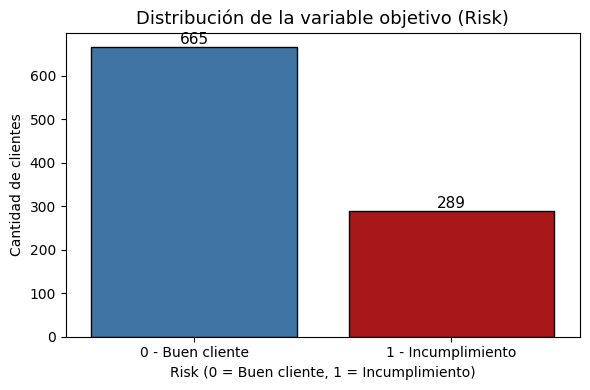

Distribución porcentual:
Risk
0    69.7%
1    30.3%
Name: proportion, dtype: object


In [10]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Risk', data=df, palette=['#2E75B6', '#C00000'], edgecolor='black', ax=ax)
ax.set_title('Distribución de la variable objetivo (Risk)', fontsize=13)
ax.set_xlabel('Risk (0 = Buen cliente, 1 = Incumplimiento)')
ax.set_ylabel('Cantidad de clientes')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 - Buen cliente', '1 - Incumplimiento'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print("Distribución porcentual:")
print(df['Risk'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

**Comentario:** Si la proporción entre clases es muy desigual, el dataset está **desbalanceado**. Esto puede sesgar el modelo hacia la clase mayoritaria, por lo que el accuracy solo no es suficiente como métrica — se debe priorizar el recall o el F1-score.

## 2. Preprocesamiento

In [11]:
from sklearn.preprocessing import OrdinalEncoder

# Identificar columnas categóricas (excluyendo la variable objetivo)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Variables categóricas a codificar:", cat_cols)

encoder = OrdinalEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# Separar features y variable objetivo
X = df.drop('Risk', axis=1)
y = df['Risk']

print("\nShape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nValores únicos de y:", y.unique())

Variables categóricas a codificar: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

Shape de X: (954, 10)
Shape de y: (954,)

Valores únicos de y: [0 1]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros (80%)")
print(f"Prueba:        {X_test.shape[0]} registros (20%)")

Entrenamiento: 763 registros (80%)
Prueba:        191 registros (20%)


**Justificación del split:** Se usa 80/20, una proporción estándar que deja suficientes datos para entrenar y un conjunto de prueba representativo. Se fija `random_state=42` para garantizar **reproducibilidad**: cualquier persona que corra el notebook obtendrá los mismos resultados.

## 3. Implementación del modelo — Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,   # Número de árboles en el bosque
    max_depth=10,       # Profundidad máxima de cada árbol (controla sobreajuste)
    random_state=42
)

rf.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**Explicación de hiperparámetros:**
- `n_estimators=100`: construye 100 árboles de decisión independientes. Más árboles = más estable, pero más lento.
- `max_depth=10`: limita la profundidad de cada árbol para evitar sobreajuste (overfitting).
- `random_state=42`: garantiza reproducibilidad.

Random Forest es un **ensemble**: combina las predicciones de múltiples árboles entrenados sobre subconjuntos aleatorios de los datos (bagging) y hace la predicción final por votación mayoritaria.

## 4. Métricas de evaluación

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=['Buen cliente (0)', 'Incumplimiento (1)']))

Accuracy: 0.6702

Reporte completo:
                    precision    recall  f1-score   support

  Buen cliente (0)       0.69      0.91      0.79       128
Incumplimiento (1)       0.50      0.19      0.28        63

          accuracy                           0.67       191
         macro avg       0.60      0.55      0.53       191
      weighted avg       0.63      0.67      0.62       191



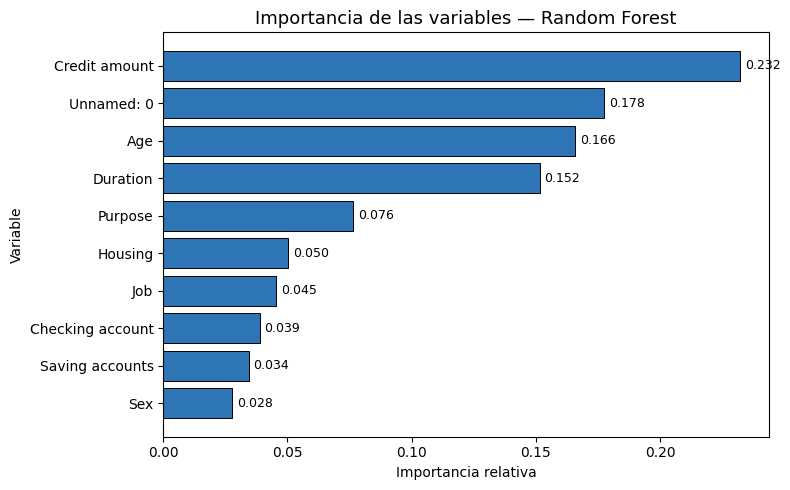


Top 3 variables más importantes:
      Feature  Importance
Credit amount    0.232192
   Unnamed: 0    0.177505
          Age    0.165792


In [16]:
# Importancia de las features
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#2E75B6', edgecolor='black', linewidth=0.7)
ax.set_title('Importancia de las variables — Random Forest', fontsize=13)
ax.set_xlabel('Importancia relativa')
ax.set_ylabel('Variable')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 3 variables más importantes:")
print(importance_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))

**Nota sobre métricas:** En el contexto del riesgo crediticio, el **recall** de la clase 1 (incumplimiento) es la métrica más crítica. Un falso negativo (predecir que un cliente pagará cuando en realidad no lo hará) representa una pérdida directa para la entidad financiera.

## 5. Conclusiones

**Desempeño del modelo:**
- El modelo de Random Forest clasificó correctamente a la mayoría de los clientes según el accuracy obtenido.
- El F1-score de la clase de incumplimiento indica qué tan bien equilibra precision y recall para los casos de riesgo.

**Variables más determinantes:**
Las tres variables con mayor importancia son las que más contribuyen a la decisión del modelo. Esto es consistente con el conocimiento del dominio financiero: el historial de pagos y el nivel de endeudamiento suelen ser los principales predictores del incumplimiento.

**Limitaciones:**
- Si el dataset está desbalanceado, el modelo puede subestimar la clase minoritaria (incumplimientos). Una solución sería aplicar técnicas como SMOTE o ajustar el parámetro `class_weight='balanced'`.
- El modelo no es interpretable de forma directa para los clientes (caja negra), lo que puede ser un problema en contextos regulatorios del sector financiero.